### Notebook for playing around with spikewrap for preprocessing

In [6]:
# Imports
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.core as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm

from probeinterface import get_probe, Probe
from probeinterface.plotting import plot_probe
from dotenv import load_dotenv, find_dotenv
from pathlib import Path

#### Specify environment variables and load config

In [19]:
load_dotenv()
repo_root = Path(find_dotenv()).parent

raw_data_dir = Path(os.getenv("RAW_DATA_DIR"))
data_fname = Path(os.getenv("TEST_DATA_FNAME"))
derivatives_dir = Path(os.getenv("DERIVATIVES_DIR"))
waveforms_dir = Path(os.getenv("WAVEFORMS_DIR"))
full_data_path = os.path.join(raw_data_dir, data_fname)
config_path = os.path.join(repo_root, "config/preprocessing.yml")
sorting_output_dir = os.path.join(derivatives_dir, "sorting_output")

# Load preprocessing config
with open(Path(config_path)) as f:
    config = yaml.safe_load(f)
    
sample_rate = config['recording']['sample_rate']
n_channels = config['recording']['n_channels']
dtype = config['recording']['dtype']
freq_min = config['preprocessing']['bandpass_filter']['freq_min']
freq_max = config['preprocessing']['bandpass_filter']['freq_max']
reference = config['preprocessing']['common_reference']['reference']
operator = config['preprocessing']['common_reference']['operator']

#### Read binary file

In [9]:
recording = se.read_binary(full_data_path, sample_rate, dtype, n_channels)

#### Get probe info and add to recording object

Probe - imec - NP2013 - 5120ch - 4shanks
Total contacts: 5120
Shanks: ['0' '1' '2' '3']
Shank 0 contacts: 1280
Y range on shank 0: 0 - 9585 um


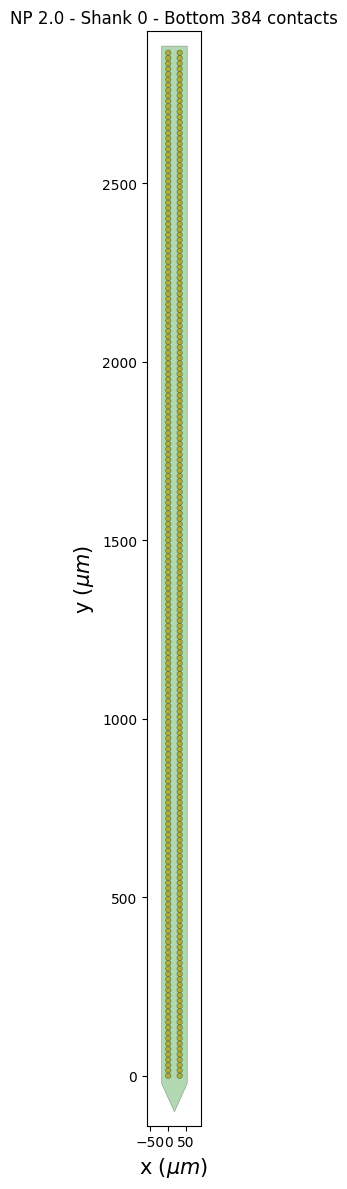

In [10]:
probe_full = get_probe("imec", "NP2013")

print(probe_full)
print(f"Total contacts: {probe_full.get_contact_count()}")

# Extract shank 0 contacts only
shank_ids = probe_full.shank_ids
print(f"Shanks: {np.unique(shank_ids)}")

# Get indices for shank 0
shank0_mask = probe_full.shank_ids == "0"
shank0_positions = probe_full.contact_positions[shank0_mask]
print(f"Shank 0 contacts: {shank0_mask.sum()}")
print(f"Y range on shank 0: {shank0_positions[:, 1].min():.0f} - {shank0_positions[:, 1].max():.0f} um")

# Sort shank 0 contacts by y (bottom = lowest y values)
shank0_pos = shank0_positions
sorted_idx = np.argsort(shank0_pos[:, 1])  # ascending = bottom first
bottom_384_pos = shank0_pos[sorted_idx[:384]]

probe = Probe(ndim=2, si_units="um")
probe.set_contacts(
    positions=bottom_384_pos,
    shapes="circle",
    shape_params={"radius": 7.5}
)
probe.set_device_channel_indices(np.arange(384))
probe.create_auto_shape(probe_type="tip")

fig, ax = plt.subplots(figsize=(3, 12))
plot_probe(probe, ax=ax)
ax.set_title("NP 2.0 - Shank 0 - Bottom 384 contacts")
plt.tight_layout()
plt.show()

In [11]:
recording_with_probe = recording.set_probe(probe)

#### Phase correction

In [12]:
intersample_shifts = np.arange(n_channels) % 16 / 16
recording_shifted = sp.phase_shift(recording_with_probe, inter_sample_shift=intersample_shifts)

#### Bandpass filtering

In [13]:
recording_filtered = sp.bandpass_filter(recording_shifted, freq_min=freq_min, freq_max=freq_max)

#### Common median referencing

In [14]:
recording_cmr = sp.common_reference(recording_filtered, reference=reference, operator=operator)

#### Spike sorting

In [ ]:
"""sorting = ss.run_sorter(
    "kilosort4",
    recording_cmr,
    folder=sorting_output_dir,
    remove_existing_folder=True,
    use_binary_file=False
)"""

  6%|▌         | 96/1684 [07:02<1:56:56,  4.42s/it]

In [ ]:
# Load sorting output
sorting = ss.read_sorter_folder(sorting_output_dir)

# Create a WaveformExtractor
we = si.create_sorting_analyzer(
    sorting=sorting,
    recording=recording_cmr,
    folder=waveforms_dir,
    overwrite=True
)

# Compute extensions
we.compute("random_spikes")
we.compute("waveforms")
we.compute("templates")
we.compute("noise_levels")
we.compute("unit_locations")
we.compute("spike_amplitudes")
we.compute("quality_metrics")

# Get metrics as a dataframe
metrics = we.get_extension("quality_metrics").get_data()
print(metrics)

estimate_sparsity (no parallelization):   0%|          | 0/3368 [00:00<?, ?it/s]

create_sorting_analyzer: recording does not have scaling to uV, forcing return_in_uV=False


compute_waveforms (no parallelization):   0%|          | 0/3368 [00:00<?, ?it/s]

In [ ]:
good_units = metrics[
    (metrics["isi_violations_ratio"] < 0.1) &
    (metrics["presence_ratio"] > 0.8) &
    (metrics["snr"] > 2)
].index

For inspection with Phy:

```
cd /path/to/sorter/output
conda activate sleep_sandbox
phy template-gui params.py
```